In [94]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import awkward as ak
import uproot
import glob
import os

In [95]:
def as_array(inpath,folder, varname, cut, nchunks):
    if nchunks is not None:
        files = glob.glob(os.path.join(os.path.abspath(inpath), folder, "*.root"))[:nchunks]
        path = [ f"{f}:events" for f in files ]
    else:
        path = os.path.join( os.path.abspath(inpath), folder, "*.root:events" )

    try: 
        # awkward array instead of numpy -> allows variable length elements
        #arr = uproot.concatenate( path+":events", expressions=varname, library="np")[varname]
        arr = uproot.concatenate( path, expressions=varname, cut=cut)
    except:
        branches = get_list_of_branches(folder)
        print( f"Branches found in files at path {folder}:" )
        for br in branches:
            print('  ', br)
        raise RuntimeError( f"Cannot process expression {varname} in files at path {folder}. Try combinations of branches from the list above." )

    # Return awkward array as a flattened ndarray
    return arr

In [96]:
input = "/r02/lhcb/ejnw2/fcc_2025/FCCAnalyses/examples/FCCee/flavour/B2Inv/outputs/prelim_cuts_noPV_ntracks_cut"
vars = ["Rec_vtx_thrustCosTheta", "Rec_vtx_in_hemisEmin","Rec_vtx_thrustCosTheta_d2PV", "Rec_vtx_in_hemisEmin_d2PV","Rec_vtx_isPV","Rec_vtx_d2PV_x","Rec_vtx_d2PV_y","Rec_vtx_d2PV_z","Rec_vtx_normd2PV_x","Rec_vtx_normd2PV_y","Rec_vtx_normd2PV_z","Rec_vtx_normd2PV","Rec_vtx_chi2"]
decay_list = ["p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu","p8_ee_Zbb_ecm91", "p8_ee_Zcc_ecm91", "p8_ee_Zss_ecm91", "p8_ee_Zud_ecm91"]+ ["p8_ee_Ztautau_ecm91","p8_ee_Zmumu_ecm91", "p8_ee_Zee_ecm91"]
cuts = "Rec_PV_ntracks>1"
df_dict={}
for decay in decay_list:
    df_dict[decay] = as_array(inpath=input,folder=decay, varname=vars, cut=cuts, nchunks=1)

In [97]:
df_dict["p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu"]


<Array [{...}, {...}, {...}, ..., {...}, {...}] type='90179 * {Rec_vtx_thru...'>

In [98]:
dict_for_df_perdecay = {}
for sample in decay_list:
    dict_for_df={}
    for variable in vars:
         dict_for_df[variable] = ak.to_numpy(ak.ravel(df_dict[sample][variable]))
    dict_for_df_perdecay[sample] = dict_for_df

In [99]:
dict_for_df_perdecay["p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu"]

{'Rec_vtx_thrustCosTheta': array([-0.99131006, -0.99625355, -0.98703724, ...,  0.9832437 ,
        -0.98992366, -0.9965716 ], dtype=float32),
 'Rec_vtx_in_hemisEmin': array([0, 0, 0, ..., 1, 0, 0], dtype=int32),
 'Rec_vtx_thrustCosTheta_d2PV': array([ 0.        , -0.99656636, -0.99240375, ...,  0.        ,
        -0.9997992 , -0.9984683 ], dtype=float32),
 'Rec_vtx_in_hemisEmin_d2PV': array([-1,  0,  0, ..., -1,  0,  0], dtype=int32),
 'Rec_vtx_isPV': array([1, 0, 0, ..., 1, 0, 0], dtype=int32),
 'Rec_vtx_d2PV_x': array([ 0.        , -0.09284212, -0.28792655, ...,  0.        ,
        -0.29959288, -2.1784866 ], dtype=float32),
 'Rec_vtx_d2PV_y': array([0.        , 0.04494467, 0.2108461 , ..., 0.        , 0.3796575 ,
        2.6495152 ], dtype=float32),
 'Rec_vtx_d2PV_z': array([0.        , 0.20305389, 0.71498054, ..., 0.        , 0.35545596,
        2.711585  ], dtype=float32),
 'Rec_vtx_normd2PV_x': array([        nan,   -4.563402,   -4.831359, ...,         nan,
         -51.349968, 

In [100]:
samples_dfs={}
for sample in decay_list:
    # Create a DataFrame from the dictionary
    df = pd.DataFrame(dict_for_df_perdecay[sample])
    samples_dfs[sample] = df[df["Rec_vtx_isPV"]==0]
    


In [8]:
decay_list_plot = ["p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu","p8_ee_Zbb_ecm91"]#, "p8_ee_Zcc_ecm91", "p8_ee_Zss_ecm91", "p8_ee_Zud_ecm91"]

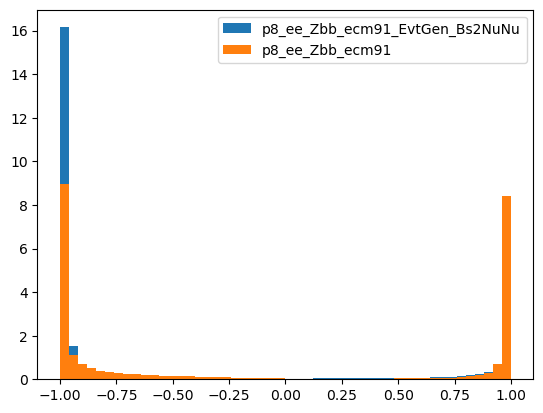

In [9]:
for sample in decay_list_plot:
    plt.hist(samples_dfs[sample]["Rec_vtx_thrustCosTheta"],bins=50,label=sample,density=True)
plt.legend()

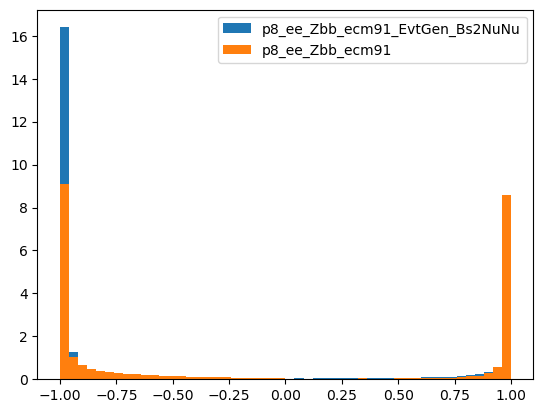

In [10]:
for sample in decay_list_plot:
    plt.hist(samples_dfs[sample]["Rec_vtx_thrustCosTheta_d2PV"],bins=50,density=True,label=sample)
plt.legend()

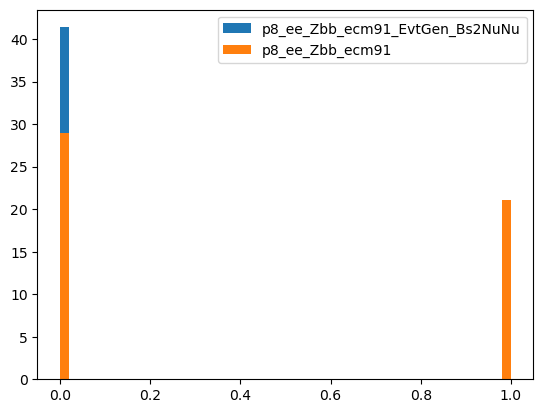

In [11]:
for sample in decay_list_plot:
    plt.hist(samples_dfs[sample]["Rec_vtx_in_hemisEmin"],bins=50,density=True,label=sample)
plt.legend()

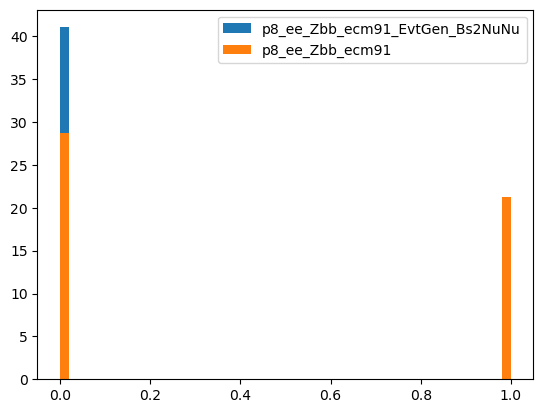

In [33]:
for sample in decay_list_plot:
    plt.hist(samples_dfs[sample]["Rec_vtx_in_hemisEmin_d2PV"],bins=50,density=True,label=sample)
plt.legend()

p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu
203193
2696
0.013268173608342808
p8_ee_Zbb_ecm91
152693
2154
0.014106737047539834
p8_ee_Zud_ecm91
13378
408
0.03049783226192256


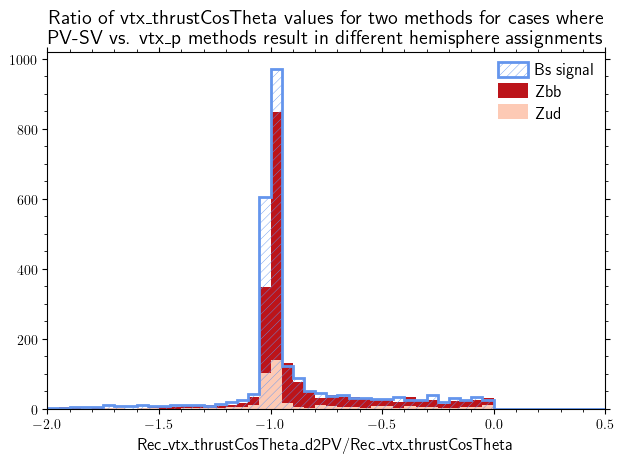

In [149]:
decay_list_plot = ["p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu","p8_ee_Zbb_ecm91", "p8_ee_Zud_ecm91",]
plt.style.use('fcc.mplstyle')
for sample in decay_list_plot:
    if sample == "p8_ee_Zbb_ecm91":
        hist_color = plt.cm.Reds_r( np.linspace(0, 1, len(cfg.sample_allocations['hadronic_background'])+2)[1] )
        label= 'Zbb'
        hist_opts = dict(histtype= 'stepfilled')
    elif sample == "p8_ee_Zud_ecm91":
        hist_color = plt.cm.Reds_r( np.linspace(0, 1, len(cfg.sample_allocations['hadronic_background'])+2)[-2] )
        label= 'Zud'
        hist_opts = dict(histtype= 'stepfilled')
    elif sample == "p8_ee_Ztautau_ecm91":
        hist_color = 'mediumvioletred'
        label= 'Ztautau'
        hist_opts = dict(hatch= '////', histtype= 'step',lw=2)
    elif sample == "p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu":
        hist_color = 'cornflowerblue'
        label= 'Bs signal'
        hist_opts = dict(hatch= '////', histtype= 'step',lw=2)
    print(sample)
    df = samples_dfs[sample]
    print(len(df))
    df_misagreement = df[df["Rec_vtx_in_hemisEmin_d2PV"]!=df["Rec_vtx_in_hemisEmin"]]
    #plt.hist(samples_dfs[sample]["Rec_vtx_in_hemisEmin_d2PV"],bins=50,density=True,label=sample)
    df_misagreement
    print(len(df_misagreement))
    print(len(df_misagreement)/len(df))
    plt.hist(df_misagreement["Rec_vtx_thrustCosTheta_d2PV"]/df_misagreement["Rec_vtx_thrustCosTheta"],bins=50,label=label,color=hist_color,range=(-2,0.5), **hist_opts)
    plt.title(r'Ratio of vtx_thrustCosTheta values for two methods for cases where'+ '\n  PV-SV vs. vtx_p methods result in different hemisphere assignments')
    plt.xlabel('Rec_vtx_thrustCosTheta_d2PV/Rec_vtx_thrustCosTheta')
    plt.legend()
plt.show()

p8_ee_Ztautau_ecm91
141275
3491
0.02471067067775615


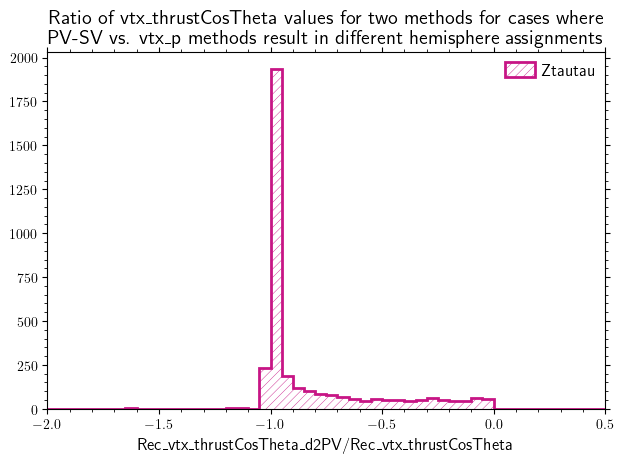

In [150]:
decay_list_plot = ["p8_ee_Ztautau_ecm91",]#"p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu"]
plt.style.use('fcc.mplstyle')
for sample in decay_list_plot:
    if sample == "p8_ee_Zbb_ecm91":
        hist_color = plt.cm.Reds_r( np.linspace(0, 1, len(cfg.sample_allocations['hadronic_background'])+2)[1] )
        label= 'Zbb'
        hist_opts = dict(histtype= 'stepfilled')
    elif sample == "p8_ee_Zud_ecm91":
        hist_color = plt.cm.Reds_r( np.linspace(0, 1, len(cfg.sample_allocations['hadronic_background'])+2)[-2] )
        label= 'Zud'
        hist_opts = dict(histtype= 'stepfilled')
    elif sample == "p8_ee_Ztautau_ecm91":
        hist_color = 'mediumvioletred'
        label= 'Ztautau'
        hist_opts = dict(hatch= '////', histtype= 'step',lw=2)
    elif sample == "p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu":
        hist_color = 'cornflowerblue'
        label= 'Bs signal'
        hist_opts = dict(hatch= '////', histtype= 'step',lw=2)
    print(sample)
    df = samples_dfs[sample]
    print(len(df))
    df_misagreement = df[df["Rec_vtx_in_hemisEmin_d2PV"]!=df["Rec_vtx_in_hemisEmin"]]
    #plt.hist(samples_dfs[sample]["Rec_vtx_in_hemisEmin_d2PV"],bins=50,density=True,label=sample)
    df_misagreement
    print(len(df_misagreement))
    print(len(df_misagreement)/len(df))
    plt.hist(df_misagreement["Rec_vtx_thrustCosTheta_d2PV"]/df_misagreement["Rec_vtx_thrustCosTheta"],bins=50,label=label,color=hist_color,range=(-2,0.5), **hist_opts)
    plt.title(r'Ratio of vtx_thrustCosTheta values for two methods for cases where'+ '\n  PV-SV vs. vtx_p methods result in different hemisphere assignments')
    plt.xlabel('Rec_vtx_thrustCosTheta_d2PV/Rec_vtx_thrustCosTheta')
    plt.legend()
plt.show()

In [14]:
df_misagreement

,Rec_vtx_thrustCosTheta,Rec_vtx_in_hemisEmin,Rec_vtx_thrustCosTheta_d2PV,Rec_vtx_in_hemisEmin_d2PV,Rec_vtx_isPV
43,0.788128,1,-0.434076,0,0
82,-0.962893,0,0.849001,1,0
120,0.114779,1,-0.207699,0,0
333,0.991613,1,-0.992359,0,0
669,-0.385187,0,0.391073,1,0
...,...,...,...,...,...
200589,-0.998810,0,0.998686,1,0
200887,-0.999188,0,0.867964,1,0
201187,-0.714580,0,0.715953,1,0
201300,0.999138,1,-0.974186,0,0


In [15]:
df_misagreement[np.sign(df_misagreement["Rec_vtx_thrustCosTheta"]) == np.sign(df_misagreement["Rec_vtx_thrustCosTheta_d2PV"])]

,Rec_vtx_thrustCosTheta,Rec_vtx_in_hemisEmin,Rec_vtx_thrustCosTheta_d2PV,Rec_vtx_in_hemisEmin_d2PV,Rec_vtx_isPV


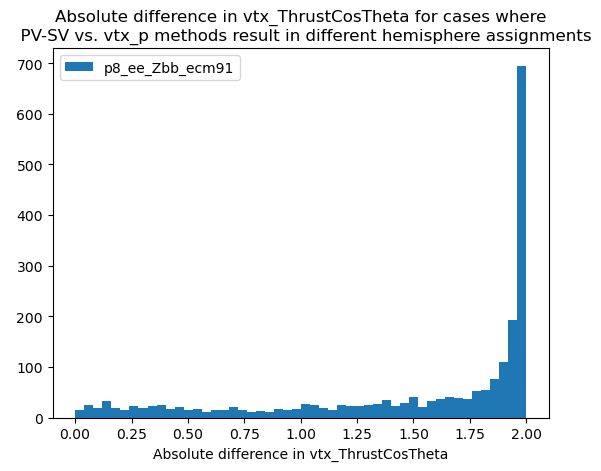

In [16]:
plt.hist(abs(df_misagreement["Rec_vtx_thrustCosTheta"]-df_misagreement["Rec_vtx_thrustCosTheta_d2PV"]),bins=50,label=sample)
plt.title(r'Absolute difference in vtx_ThrustCosTheta for cases where'+ '\n  PV-SV vs. vtx_p methods result in different hemisphere assignments')
plt.xlabel('Absolute difference in vtx_ThrustCosTheta')
plt.legend()
plt.show()

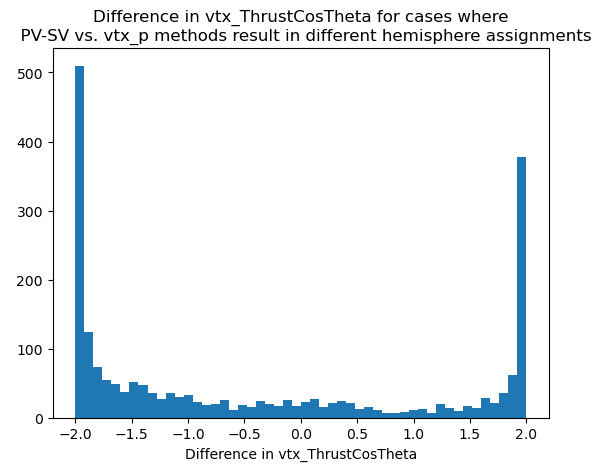

In [17]:
plt.hist((df_misagreement["Rec_vtx_thrustCosTheta"]-df_misagreement["Rec_vtx_thrustCosTheta_d2PV"]),bins=50)
plt.title(r'Difference in vtx_ThrustCosTheta for cases where'+ '\n  PV-SV vs. vtx_p methods result in different hemisphere assignments')
plt.xlabel('Difference in vtx_ThrustCosTheta')
plt.show()

In [12]:
## Now look at whole df where a row == an event
def as_np(inpath,folder, varname, cut, nchunks):
    if nchunks is not None:
        files = glob.glob(os.path.join(os.path.abspath(inpath), folder, "*.root"))[:nchunks]
        path = [ f"{f}:events" for f in files ]
    else:
        path = os.path.join( os.path.abspath(inpath), folder, "*.root:events" )


    # awkward array instead of numpy -> allows variable length elements
    #arr = uproot.concatenate( path+":events", expressions=varname, library="np")[varname]
    a = uproot.concatenate( path, expressions=varname, cut=cut, library="np" )
    print(a)
    # Return awkward array as a flattened ndarray
    return a


In [13]:
input = "/r02/lhcb/ejnw2/fcc_2025/FCCAnalyses/examples/FCCee/flavour/B2Inv/outputs/prelim_cuts_noPV_ntracks_cut"
vars = ["Rec_vtx_thrustCosTheta", "Rec_vtx_in_hemisEmin","Rec_vtx_thrustCosTheta_d2PV", "Rec_vtx_in_hemisEmin_d2PV","Rec_vtx_isPV"]
decay_list = ["p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu"]#,"p8_ee_Zbb_ecm91", "p8_ee_Zcc_ecm91", "p8_ee_Zss_ecm91", "p8_ee_Zud_ecm91"] + ["p8_ee_Ztautau_ecm91","p8_ee_Zmumu_ecm91", "p8_ee_Zee_ecm91"]
cuts = "Rec_PV_ntracks>1"
df_dict={}
for decay in decay_list:
    df_dict[decay] = pd.DataFrame(as_np(inpath=input,folder=decay, varname=vars, cut=cuts, nchunks=5))

df_dict['p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu']

{'Rec_vtx_thrustCosTheta': array([array([-0.99131006, -0.99625355, -0.98703724], dtype=float32),
       array([ 0.76557755,  0.99348235, -0.9900377 , -0.9687515 ], dtype=float32),
       array([ 0.9794538 , -0.99984086], dtype=float32), ...,
       array([ 0.9717491 , -0.98967105, -0.9914949 ], dtype=float32),
       array([-0.99513966,  0.9621951 ,  0.8964211 ], dtype=float32),
       array([-0.89311326, -0.9010278 ], dtype=float32)], dtype=object), 'Rec_vtx_in_hemisEmin': array([array([0, 0, 0], dtype=int32), array([1, 1, 0, 0], dtype=int32),
       array([1, 0], dtype=int32), ..., array([1, 0, 0], dtype=int32),
       array([0, 1, 1], dtype=int32), array([0, 0], dtype=int32)],
      dtype=object), 'Rec_vtx_thrustCosTheta_d2PV': array([array([ 0.        , -0.99656636, -0.99240375], dtype=float32),
       array([ 0.        ,  0.9933216 , -0.98356324, -0.9810498 ], dtype=float32),
       array([ 0.      , -0.999918], dtype=float32), ...,
       array([ 0.       , -0.9955851, -0.9967417

,Rec_vtx_thrustCosTheta,Rec_vtx_in_hemisEmin,Rec_vtx_thrustCosTheta_d2PV,Rec_vtx_in_hemisEmin_d2PV,Rec_vtx_isPV
0,"[-0.99131006, -0.99625355, -0.98703724]","[0, 0, 0]","[0.0, -0.99656636, -0.99240375]","[-1, 0, 0]","[1, 0, 0]"
1,"[0.76557755, 0.99348235, -0.9900377, -0.9687515]","[1, 1, 0, 0]","[0.0, 0.9933216, -0.98356324, -0.9810498]","[-1, 1, 0, 0]","[1, 0, 0, 0]"
2,"[0.9794538, -0.99984086]","[1, 0]","[0.0, -0.999918]","[-1, 0]","[1, 0]"
3,"[0.964874, 0.97771424, -0.98180187]","[1, 1, 0]","[0.0, 0.9776688, -0.98804855]","[-1, 1, 0]","[1, 0, 0]"
4,"[-0.6455715, -0.99666125, -0.98908794]","[0, 0, 0]","[0.0, -0.9966861, -0.99501985]","[-1, 0, 0]","[1, 0, 0]"
...,...,...,...,...,...
541576,"[0.4996939, -0.98218626, -0.95833075]","[1, 0, 0]","[0.0, -0.9760235, -0.95860577]","[-1, 0, 0]","[1, 0, 0]"
541577,"[-0.91005796, 0.8891378, 0.95257264, 0.9475708]","[0, 1, 1, 1]","[0.0, 0.88983816, 0.95240766, 0.95185673]","[-1, 1, 1, 1]","[1, 0, 0, 0]"
541578,"[0.9717491, -0.98967105, -0.9914949]","[1, 0, 0]","[0.0, -0.9955851, -0.9967417]","[-1, 0, 0]","[1, 0, 0]"
541579,"[-0.99513966, 0.9621951, 0.8964211]","[0, 1, 1]","[0.0, 0.95335454, 0.8970663]","[-1, 1, 1]","[1, 0, 0]"


In [27]:
filtered_dict={}
for decay in decay_list:
    ddd = df_dict[decay]
    arry=[]
    for i in range(len(ddd)):
        comparison = np.equal(ddd["Rec_vtx_in_hemisEmin"][i][1:], ddd["Rec_vtx_in_hemisEmin_d2PV"][i][1:])
        arry.append(comparison.all())
    # Return False if any pair doesn't match
    
    count = arry.count(False)
    ddd["vtx_assignment_agreement"] = arry
    print(decay)
    print(f"Frac to remove {count/len(arry)}")
    print(len(arry))
    print(len(ddd))
    print(len(ddd[ddd["vtx_assignment_agreement"]==True]))
    filtered_dict[decay] = ddd[ddd["vtx_assignment_agreement"]==True]
        

p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu
Frac to remove 0.02905197929764892
541581
541581
525847


In [23]:
ddd

,Rec_vtx_thrustCosTheta,Rec_vtx_in_hemisEmin,Rec_vtx_thrustCosTheta_d2PV,Rec_vtx_in_hemisEmin_d2PV,Rec_vtx_isPV,vtx_assignment_agreement
0,"[-0.99131006, -0.99625355, -0.98703724]","[0, 0, 0]","[0.0, -0.99656636, -0.99240375]","[-1, 0, 0]","[1, 0, 0]",True
1,"[0.76557755, 0.99348235, -0.9900377, -0.9687515]","[1, 1, 0, 0]","[0.0, 0.9933216, -0.98356324, -0.9810498]","[-1, 1, 0, 0]","[1, 0, 0, 0]",True
2,"[0.9794538, -0.99984086]","[1, 0]","[0.0, -0.999918]","[-1, 0]","[1, 0]",True
3,"[0.964874, 0.97771424, -0.98180187]","[1, 1, 0]","[0.0, 0.9776688, -0.98804855]","[-1, 1, 0]","[1, 0, 0]",True
4,"[-0.6455715, -0.99666125, -0.98908794]","[0, 0, 0]","[0.0, -0.9966861, -0.99501985]","[-1, 0, 0]","[1, 0, 0]",True
...,...,...,...,...,...,...
541576,"[0.4996939, -0.98218626, -0.95833075]","[1, 0, 0]","[0.0, -0.9760235, -0.95860577]","[-1, 0, 0]","[1, 0, 0]",True
541577,"[-0.91005796, 0.8891378, 0.95257264, 0.9475708]","[0, 1, 1, 1]","[0.0, 0.88983816, 0.95240766, 0.95185673]","[-1, 1, 1, 1]","[1, 0, 0, 0]",True
541578,"[0.9717491, -0.98967105, -0.9914949]","[1, 0, 0]","[0.0, -0.9955851, -0.9967417]","[-1, 0, 0]","[1, 0, 0]",True
541579,"[-0.99513966, 0.9621951, 0.8964211]","[0, 1, 1]","[0.0, 0.95335454, 0.8970663]","[-1, 1, 1]","[1, 0, 0]",True


In [44]:
import ROOT
import os


# Function to load data using ROOT and apply cut
def as_df(inpath, folder, varname, cut, nchunks):
    if nchunks is not None:
        files = [os.path.join(os.path.abspath(inpath), folder, f) for f in os.listdir(os.path.join(os.path.abspath(inpath), folder)) if f.endswith('.root')][:nchunks]
    else:
        files = [os.path.join(os.path.abspath(inpath), folder, f) for f in os.listdir(os.path.join(os.path.abspath(inpath), folder)) if f.endswith('.root')]

    chain = ROOT.TChain("events")
    for f in files:
        chain.Add(f)

    df = ROOT.RDataFrame(chain)
    df = df.Filter(cut)
    
    data = {}
    for var in varname:
        data[var] = df.AsNumpy([var])[var]

    return data

def create_filtered_tree(input_path, decay, vars, filtered_data):
    out_file = ROOT.TFile(f"{input_path}/{decay}/filtered_output.root", "RECREATE")
    out_tree = ROOT.TTree("events", "Filtered Events")

    branches = {var: ROOT.std.vector('float')() for var in vars}
    branches["vtx_assignment_agreement"] = ROOT.std.vector('bool')()
    
    for var in branches:
        out_tree.Branch(var, branches[var])

    for i in range(len(filtered_data[vars[0]])):
        for var in vars:
            branches[var].clear()
            for val in filtered_data[var][i]:
                branches[var].push_back(val)
        branches["vtx_assignment_agreement"].clear()
        branches["vtx_assignment_agreement"].push_back(filtered_data["vtx_assignment_agreement"][i])
        out_tree.Fill()

    out_tree.Write()
    out_file.Close()

input = "/r02/lhcb/ejnw2/fcc_2025/FCCAnalyses/examples/FCCee/flavour/B2Inv/outputs/prelim_cuts_noPV_ntracks_cut"
vars = ["Rec_vtx_thrustCosTheta", "Rec_vtx_in_hemisEmin","Rec_vtx_thrustCosTheta_d2PV", "Rec_vtx_in_hemisEmin_d2PV","Rec_vtx_isPV"]
decay_list = ["p8_ee_Zbb_ecm91"]  
cuts = "Rec_PV_ntracks>1"

df_dict = {}
for decay in decay_list:
    df_dict[decay] = as_df(inpath=input, folder=decay, varname=vars, cut=cuts, nchunks=5)

filtered_dict = {}
for decay in decay_list:
    ddd = df_dict[decay]
    arry = []
    for i in range(len(ddd["Rec_vtx_in_hemisEmin"])):
        comparison = all(ddd["Rec_vtx_in_hemisEmin"][i][j] == ddd["Rec_vtx_in_hemisEmin_d2PV"][i][j] for j in range(1, len(ddd["Rec_vtx_in_hemisEmin"][i])))
        arry.append(comparison)
    
    ddd["vtx_assignment_agreement"] = arry
    filtered_dict[decay] = {key: [val[i] for i in range(len(arry)) if arry[i]] for key, val in ddd.items()}
    
    print(decay)
    print(f"Frac to remove {arry.count(False)/len(arry)}")
    print(len(arry))
    print(len(ddd["Rec_vtx_in_hemisEmin"]))
    print(len(filtered_dict[decay]["Rec_vtx_in_hemisEmin"]))

# Save the filtered data back to new ROOT files
#for decay in filtered_dict:
#    create_filtered_tree(input, decay, vars, filtered_dict[decay])


p8_ee_Zbb_ecm91
Frac to remove 0.0438458079895486
235758
235758
225421


In [71]:
d = filtered_dict['p8_ee_Zbb_ecm91']
any(d['vtx_assignment_agreement']) ==False

False

In [72]:
len(d['vtx_assignment_agreement'])

225421

## Investigating Cause

In [101]:
decay = 'p8_ee_Zbb_ecm91'
bb_df=samples_dfs[decay]

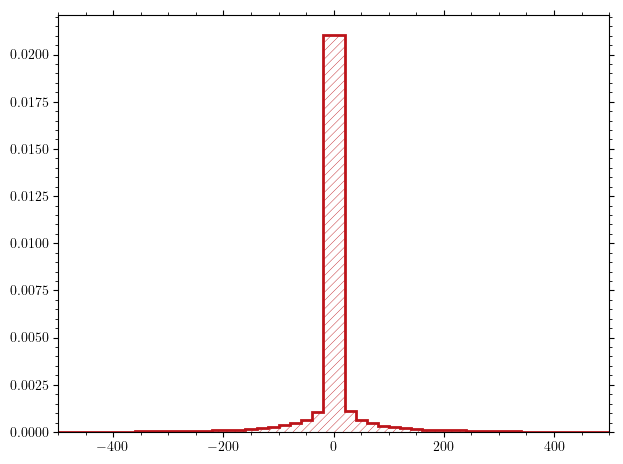

In [102]:
import config as cfg
plt.style.use('fcc.mplstyle')
hist_opts = dict( stacked=False, histtype='step', lw=2 )
hist_opts['color'] = plt.cm.Reds_r( np.linspace(0, 1, len(cfg.sample_allocations['hadronic_background'])+2)[1] )
hist_opts['hatch'] = '////'

fig, ax = plt.subplots()
ax.hist( 
    x = bb_df['Rec_vtx_d2PV_x'],
    bins = 50,
    density = True,
    range=(-500,500),
    label = 'p8_ee_Zbb_ecm91',
    **hist_opts
)
plt.show()


In [161]:
import config as cfg
plt.style.use('fcc.mplstyle')

def simple_bb_plotter(variable,cut,xrange):
    hist_opts = dict( stacked=False, histtype='step', lw=2 )
    hist_opts['color'] = plt.cm.Reds_r( np.linspace(0, 1, len(cfg.sample_allocations['hadronic_background'])+2)[1] )
    hist_opts['hatch'] = '////'

    if cut is not None:
        hist_x = bb_df[variable]
    elif cut == "discrepant_vtx_hemis_assignment":
        hist_x = bb_df[bb_df["Rec_vtx_in_hemisEmin_d2PV"]!=bb_df["Rec_vtx_in_hemisEmin"]][variable]
    elif cut == "discrepant_vtx_hemis_assignment_removed":
        hist_x = bb_df[bb_df["Rec_vtx_in_hemisEmin_d2PV"]==bb_df["Rec_vtx_in_hemisEmin"]][variable]
            
            
    fig, ax = plt.subplots()
    ax.hist( 
        x = hist_x,
        bins = 50,
        density = True,
        range=xrange,
        label = 'p8_ee_Zbb_ecm91',
        **hist_opts
    )
    if cut is not None:
        ax.set_xlabel(f"{variable} (cut={cut})")
    else:
        ax.set_xlabel(f"{variable} (cut={cut})")
    ax.set_ylabel('Density')
    ax.legend()
    #plt.show()

In [135]:
def simple_bb_2fig_plotter(variable,xrange):
    hist_opts = dict( stacked=False, histtype='step', lw=2 )
    hist_opts['color'] = plt.cm.Reds_r( np.linspace(0, 1, len(cfg.sample_allocations['hadronic_background'])+2)[1] )
    hist_opts['hatch'] = '////'

    hist_opts2 = dict( stacked=False, histtype='step', lw=2 )
    hist_opts2['color'] = plt.cm.Reds_r( np.linspace(0, 1, len(cfg.sample_allocations['hadronic_background'])+2)[1] )
    hist_opts2['hatch'] = r'\\\\'

    hist_x = bb_df[variable]
    hist_x_cut = bb_df[bb_df["Rec_vtx_in_hemisEmin_d2PV"]!=bb_df["Rec_vtx_in_hemisEmin"]][variable]
    cut = "discrepant vtx hemis assignment"
            
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4),sharey=True)
    ax1.hist( 
        x = hist_x,
        bins = 50,
        density = True,
        range=xrange,
        label = r"$Z \to b \bar{b}$"+f", \n2025  prelim cuts \n(incl. valid PV fit)",
        **hist_opts
    )
    ax2.hist( 
        x = hist_x_cut,
        bins = 50,
        density = True,
        range=xrange,
        label = r"$Z \to b \bar{b}$"+f", \nvertices with\ndiscrepant vtx \nhemis assignment",
        **hist_opts2
    )

    ax1.set_xlabel(variable)
    ax2.set_xlabel(variable)
    ax1.set_ylabel('Density')
    ax1.legend()
    ax2.legend()
    plt.show()

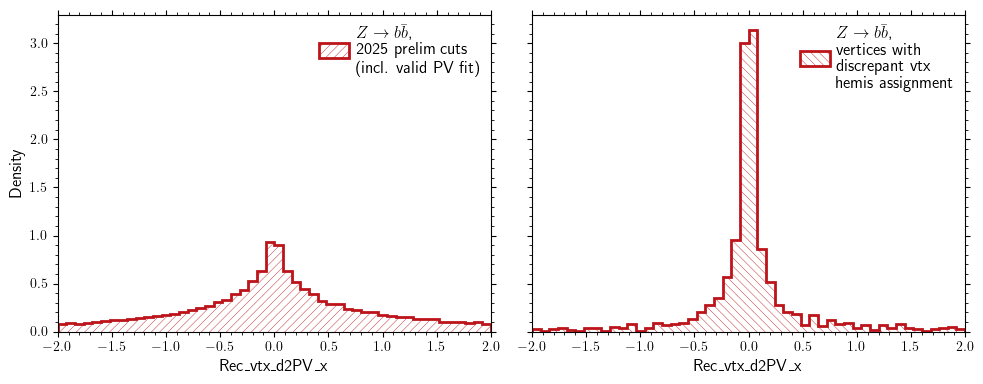

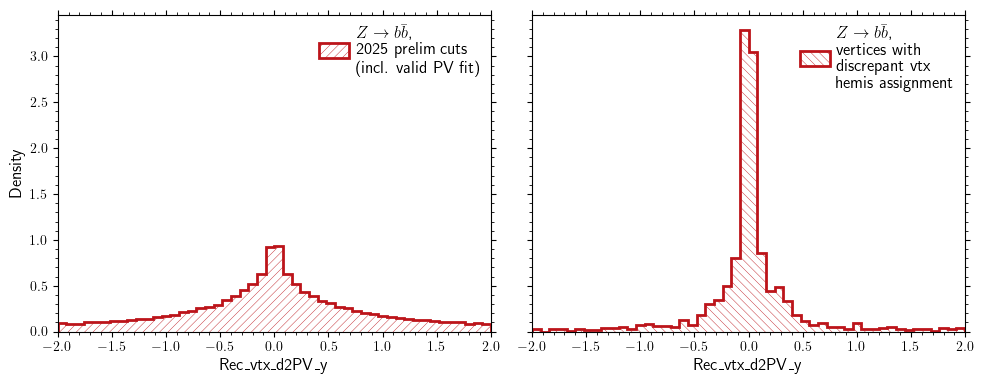

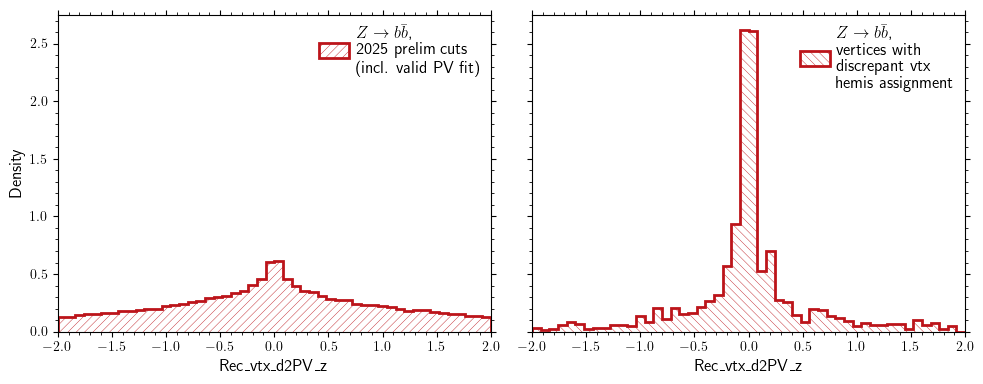

In [136]:
simple_bb_2fig_plotter("Rec_vtx_d2PV_x", (-2,2))
simple_bb_2fig_plotter("Rec_vtx_d2PV_y", (-2,2))
simple_bb_2fig_plotter("Rec_vtx_d2PV_z", (-2,2))

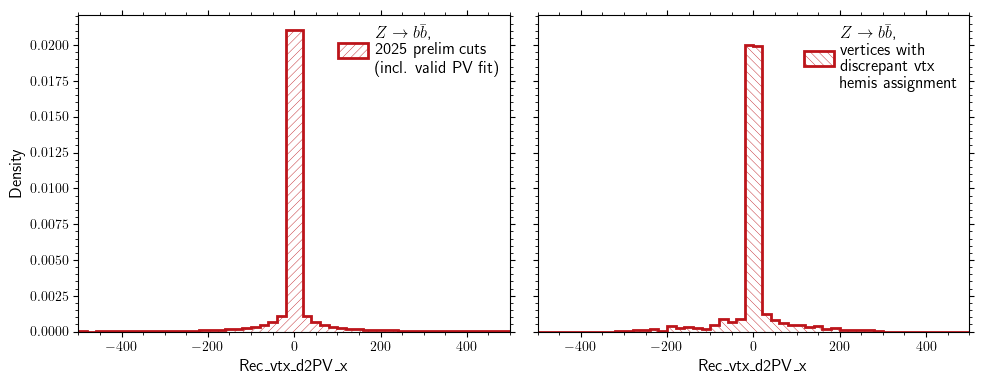

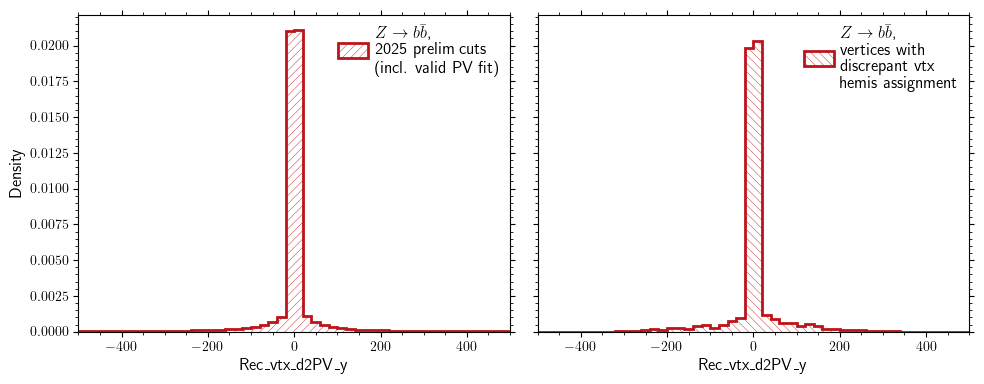

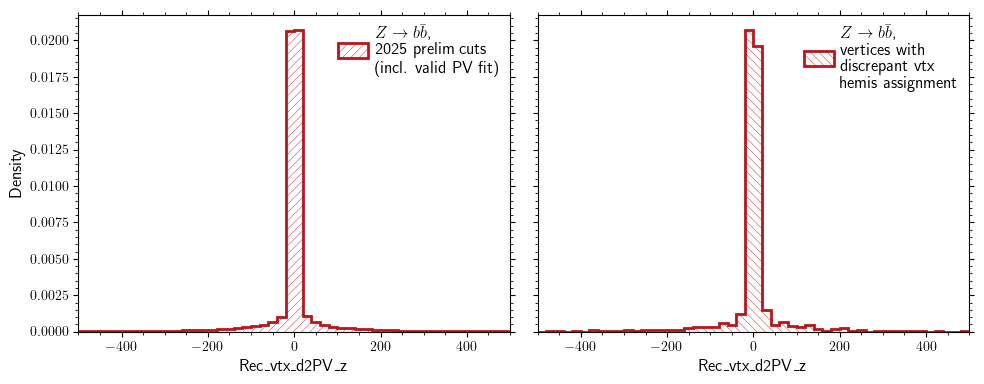

In [137]:
simple_bb_2fig_plotter("Rec_vtx_d2PV_x", (-500,500))
simple_bb_2fig_plotter("Rec_vtx_d2PV_y", (-500,500))
simple_bb_2fig_plotter("Rec_vtx_d2PV_z", (-500,500))

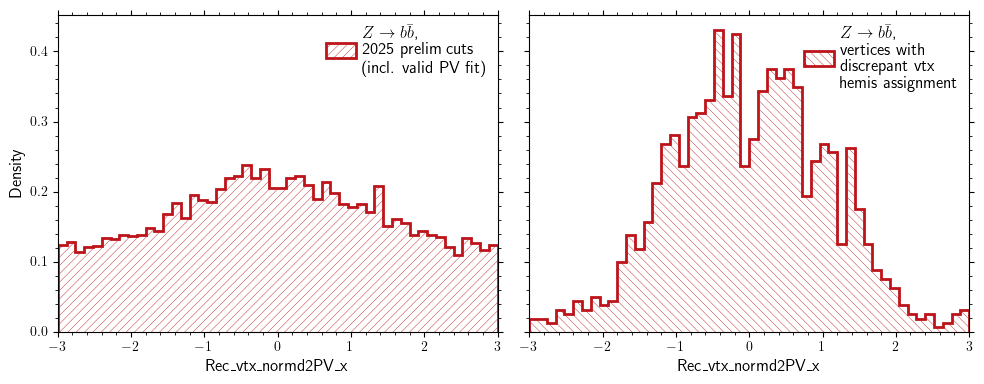

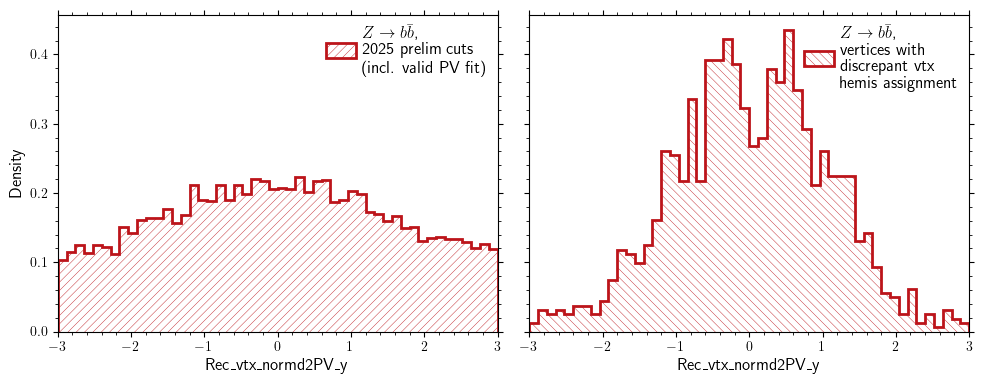

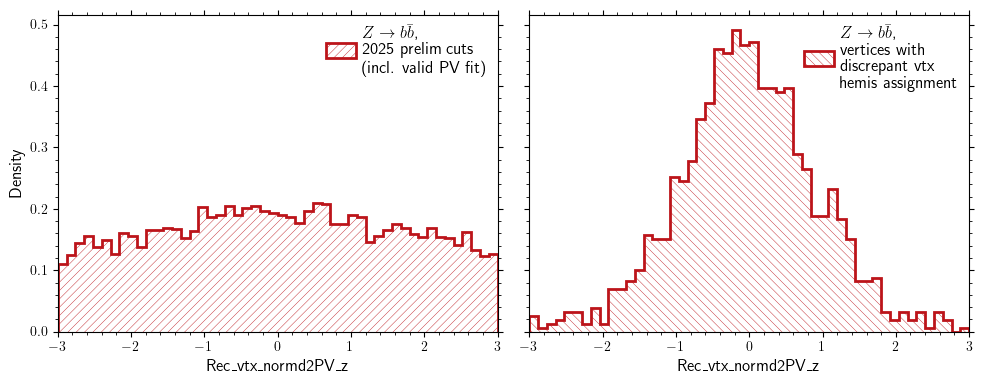

In [138]:
simple_bb_2fig_plotter("Rec_vtx_normd2PV_x", (-3,3))
simple_bb_2fig_plotter("Rec_vtx_normd2PV_y", (-3,3))
simple_bb_2fig_plotter("Rec_vtx_normd2PV_z", (-3,3))

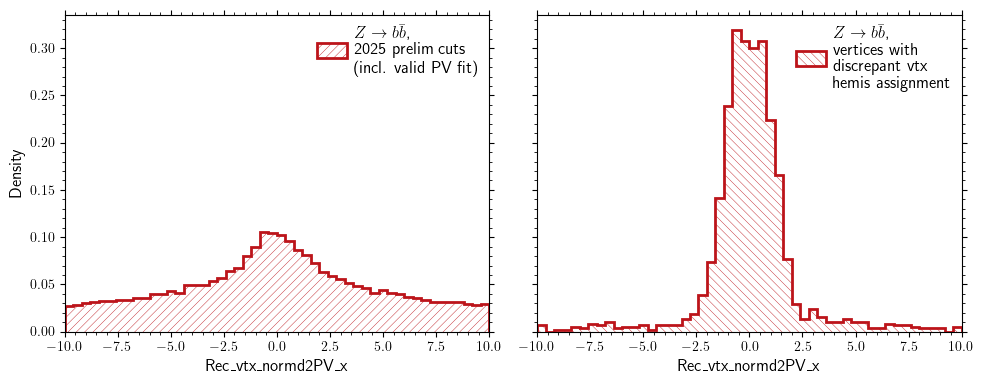

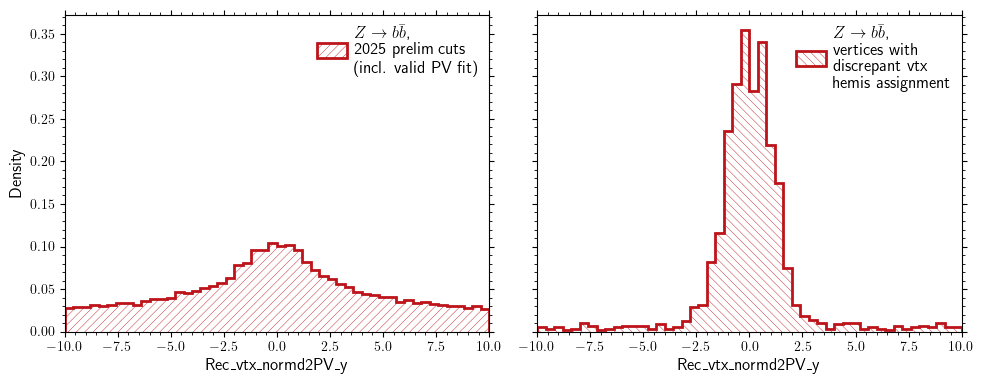

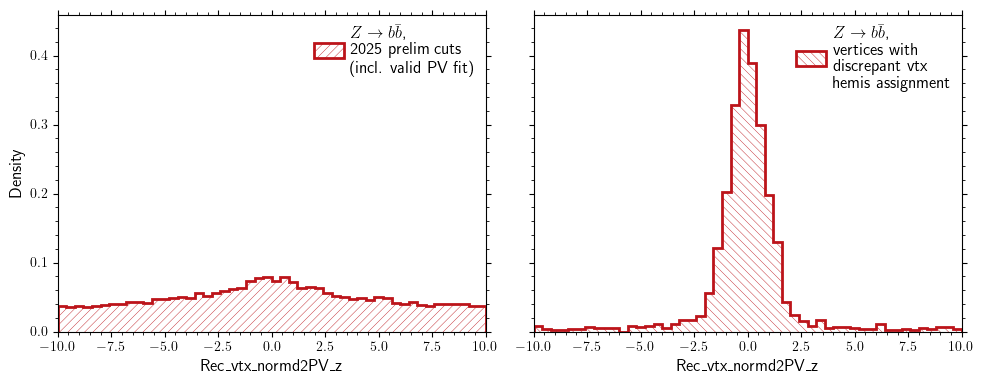

In [139]:
simple_bb_2fig_plotter("Rec_vtx_normd2PV_x", (-10,10))
simple_bb_2fig_plotter("Rec_vtx_normd2PV_y", (-10,10))
simple_bb_2fig_plotter("Rec_vtx_normd2PV_z", (-10,10))

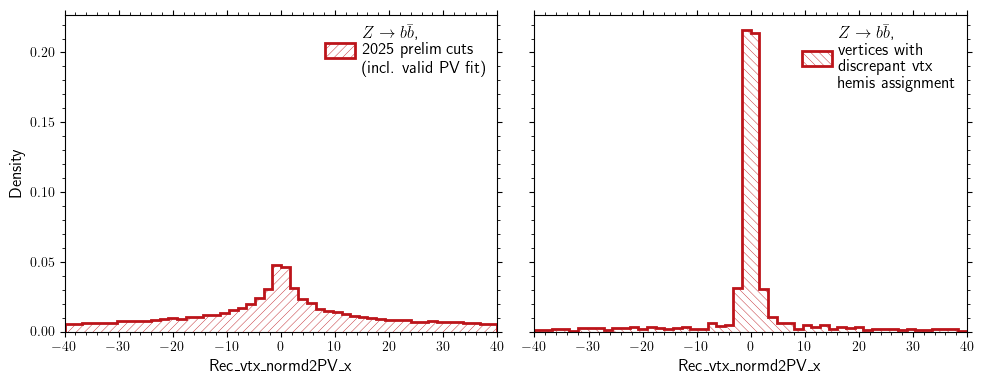

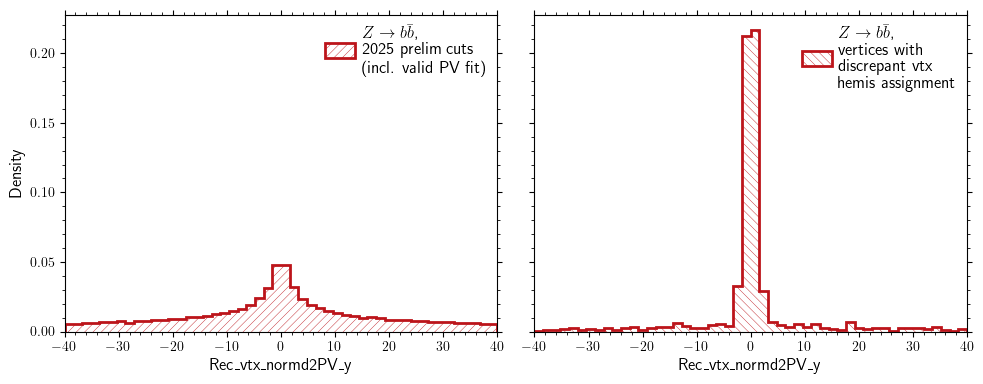

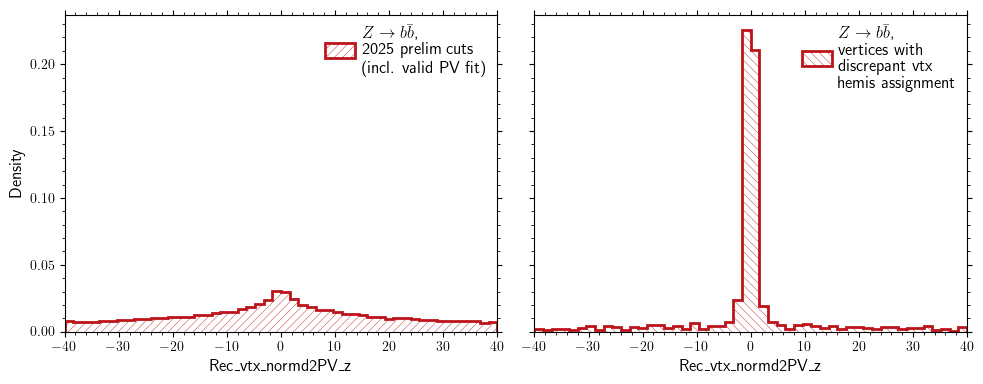

In [140]:
simple_bb_2fig_plotter("Rec_vtx_normd2PV_x", (-40,40))
simple_bb_2fig_plotter("Rec_vtx_normd2PV_y", (-40,40))
simple_bb_2fig_plotter("Rec_vtx_normd2PV_z", (-40,40))

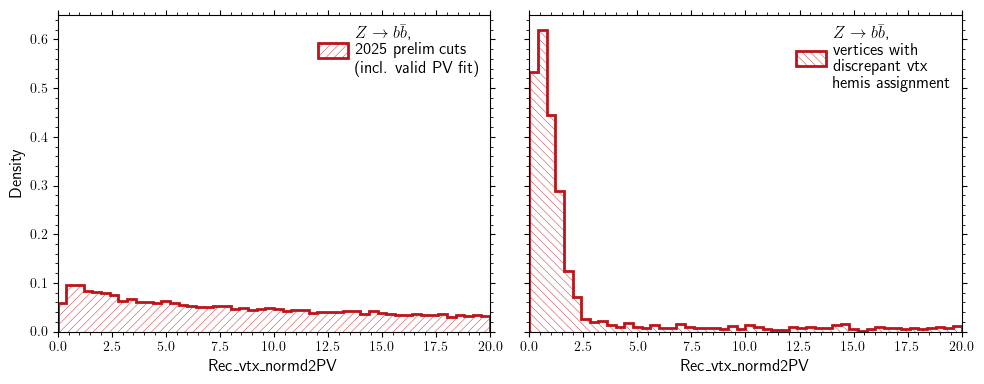

In [141]:
simple_bb_2fig_plotter("Rec_vtx_normd2PV", (0,20))

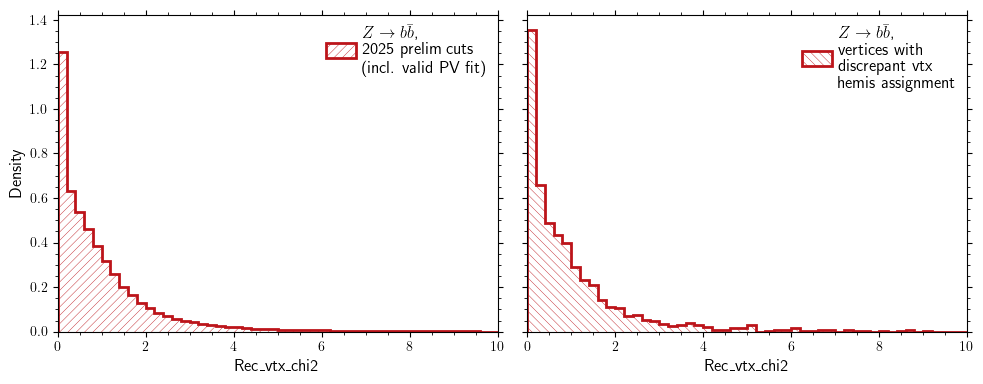

In [153]:
simple_bb_2fig_plotter("Rec_vtx_chi2", (0,10))

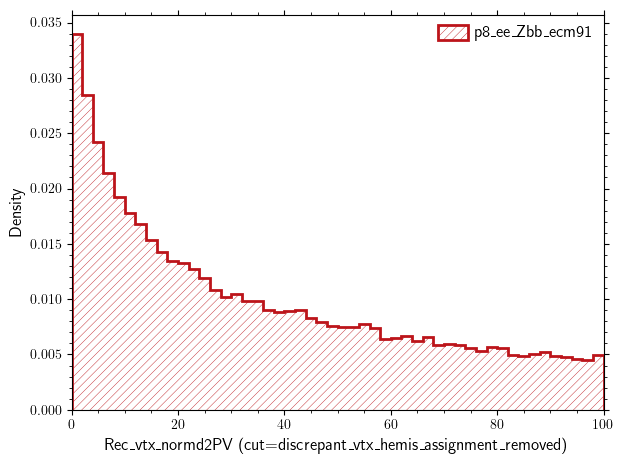

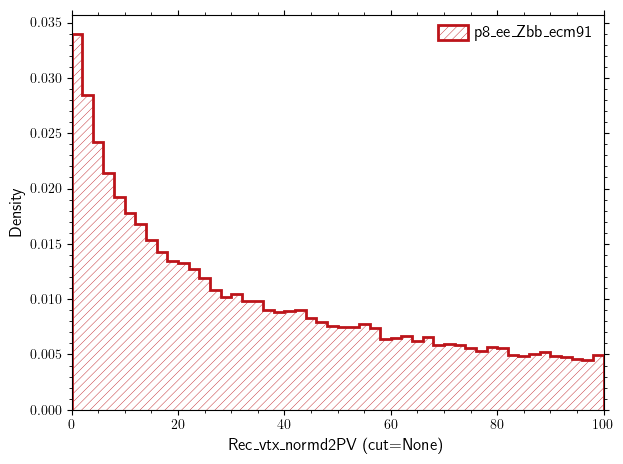

In [164]:
simple_bb_plotter("Rec_vtx_normd2PV","discrepant_vtx_hemis_assignment_removed", (0,100))
simple_bb_plotter("Rec_vtx_normd2PV","None", (0,100))
plt.show()

## Testing python script to do this for all data

In [2]:
#function to read root data one file at a time
def read_root_data(inpath, folder, varnames, cut,chunk_index=0):
    """Reads event data and TParameters from ROOT files."""

    # Get the list of ROOT files in the specified folder and select one requested by start index
    file = sorted(glob.glob(os.path.join(os.path.abspath(inpath), folder, "chunk_*.root")))[chunk_index]

    # Read event data using uproot
    event_data = uproot.concatenate([f"{file}:events"], expressions=varnames, cut=cut, library="np")
    

    # Read TParameters from the file
    root_file = uproot.open(file)

    # Fetch the TParameters as integers, with a default of 0 if not present
    events_processed = root_file.get("eventsProcessed", 0).value  # Events processed in tupling
    print(f"eventsProcessed = {events_processed}")
    events_selected = root_file.get("eventsSelected", 0).value    # Events selected by tupling (excludes PVfit cut)
    print(f"eventsSelected = {events_selected}")
    #return chunk processed as string
    chunk_processed = os.path.basename(file).replace(".root", "")
    
    return pd.DataFrame(event_data), events_processed, events_selected, chunk_processed

In [3]:
tupling_output_path = "/r02/lhcb/ejnw2/fcc_2025/FCCAnalyses/examples/FCCee/flavour/B2Inv/outputs/" 
data_folder = "test" #"prelim_cuts_noPV_ntracks_cut" # to change post test
input = os.path.join(os.path.abspath(tupling_output_path), data_folder)
vars = ["Rec_vtx_thrustCosTheta", "Rec_vtx_in_hemisEmin","Rec_vtx_thrustCosTheta_d2PV", "Rec_vtx_in_hemisEmin_d2PV","Rec_vtx_isPV"] #to change to all vars from B2inv yaml
decay_list = ["p8_ee_Zbb_ecm91"]  # to change to full list from yaml
cuts = "Rec_PV_ntracks>1"

In [5]:
for decay in decay_list:
    print(f"Decay: {decay}")
    # Loop over each chunk of data for each decay
    for index in range(0, len(glob.glob(os.path.join(os.path.abspath(input), decay, "chunk_*.root"))), 1):

        # Read data and TParameters (eventsProcessed, eventsSelected) for each decay sample
        df, events_processed, events_selected, chunk_processed = read_root_data(inpath=input, folder=decay, varnames=vars, cut=cuts, chunk_index=index)
       
        matching_results = []
        # Loop over events and compare the jagged arrays
        for i in range(len(df)):
            comparison = np.equal(df["Rec_vtx_in_hemisEmin"][i][1:], df["Rec_vtx_in_hemisEmin_d2PV"][i][1:])
            matching_results.append(comparison.all())  # Check if all elements match
    
        # Count the events to remove (where comparison is False)
        count_false = matching_results.count(False)
        total_events = len(matching_results)
        
        # Update eventsProcessed and eventsSelected based on filtering
        events_processed_post_PVfit_cut = total_events
        events_selected_after_both_cuts = total_events - count_false
    
       
        print(f"Chunk: {chunk_processed}")
        print(f"Total events pre cuts: {events_selected}")
        print(f"Total events post cuts (PV reconstriction and vertex pointing): {events_selected_after_both_cuts}")
        print(f"Fraction removed by two cuts: {events_selected_after_both_cuts/events_selected}")

        

Decay: p8_ee_Zbb_ecm91
eventsProcessed = 800000
eventsSelected = 49038
Chunk: chunk_0
Total events pre cuts: 49038
Total events post cuts (PV reconstriction and vertex pointing): 46587
Fraction removed by two cuts: 0.9500183531139117
eventsProcessed = 800000
eventsSelected = 48737
Chunk: chunk_1
Total events pre cuts: 48737
Total events post cuts (PV reconstriction and vertex pointing): 46208
Fraction removed by two cuts: 0.9481092393869134


In [2]:
# look at saved files

# file location Bs signal
filepath = "/r02/lhcb/ejnw2/fcc_2025/FCCAnalyses/examples/FCCee/flavour/B2Inv/outputs/prelim_and_PVreco_vtxassignment_cuts/p8_ee_Zbb_ecm91/chunk_0.root"
vars = ["Rec_vtx_thrustCosTheta", "Rec_vtx_in_hemisEmin","Rec_vtx_thrustCosTheta_d2PV", "Rec_vtx_in_hemisEmin_d2PV","Rec_vtx_isPV"] #to change to all vars from B2inv yaml

# Create instance of uproot, we have opened the file
uproot_file = uproot.open( filepath)

# We want output events
tree = uproot_file['events']

df_test= tree.arrays(
    expressions =  vars, 
    library = 'pd' ,
)

In [3]:
df_test

,Rec_vtx_thrustCosTheta,Rec_vtx_in_hemisEmin,Rec_vtx_thrustCosTheta_d2PV,Rec_vtx_in_hemisEmin_d2PV,Rec_vtx_isPV
0,"[-0.9899690747261047, -0.9668017029762268, -0....","[0, 0, 0, 1, 0, 1]","[0.0, -0.8955221772193909, -0.9932315945625305...","[-1, 0, 0, 1, 0, 1]","[1, 0, 0, 0, 0, 0]"
1,"[-0.9512506127357483, 0.9986923933029175]","[0, 1]","[0.0, 0.9991597533226013]","[-1, 1]","[1, 0]"
2,"[-0.48582178354263306, 0.7828604578971863, -0....","[0, 1, 0, 1, 1]","[0.0, 0.7829529643058777, -0.8783515095710754,...","[-1, 1, 0, 1, 1]","[1, 0, 0, 0, 0]"
3,"[-0.06829912215471268, -0.9995086193084717, -0...","[0, 0, 0]","[0.0, -0.9936516880989075, -0.9922152161598206]","[-1, 0, 0]","[1, 0, 0]"
4,"[0.9367514252662659, 0.7408124804496765, 0.950...","[1, 1, 1, 0, 0, 1]","[0.0, 0.7408996224403381, 0.9440012574195862, ...","[-1, 1, 1, 0, 0, 1]","[1, 0, 0, 0, 0, 0]"
...,...,...,...,...,...
46582,"[-0.07532189041376114, 0.18506291508674622, -0...","[0, 1, 0]","[0.0, 0.18609467148780823, -0.9290344715118408]","[-1, 1, 0]","[1, 0, 0]"
46583,"[-0.9507573843002319, 0.9958816766738892, -0.9...","[0, 1, 0, 0]","[0.0, 0.9979037642478943, -0.9875563979148865,...","[-1, 1, 0, 0]","[1, 0, 0, 0]"
46584,"[-0.9403311610221863, 0.9985202550888062]","[0, 1]","[0.0, 0.9995126128196716]","[-1, 1]","[1, 0]"
46585,"[0.9995852112770081, 0.9345690011978149, -0.99...","[1, 1, 0, 1, 0]","[0.0, 0.9349449872970581, -0.9999599456787109,...","[-1, 1, 0, 1, 0]","[1, 0, 0, 0, 0]"


In [6]:
df_testak= tree.arrays(
    expressions =  vars, 
    library = 'np' ,
)

In [7]:
df_testak

{'Rec_vtx_thrustCosTheta': array([array([-0.98996907, -0.9668017 , -0.99316037,  0.99496096, -0.721412  ,
                0.99574304])                                                   ,
        array([-0.95125061,  0.99869239]),
        array([-0.48582178,  0.78286046, -0.87867177,  0.95732903,  0.91318023]),
        ..., array([-0.94033116,  0.99852026]),
        array([ 0.99958521,  0.934569  , -0.9920553 ,  0.99622047, -0.99417824]),
        array([ 0.098358  , -0.97998452, -0.2278064 ,  0.70434928,  0.9989081 ])],
       dtype=object),
 'Rec_vtx_in_hemisEmin': array([array([0, 0, 0, 1, 0, 1]), array([0, 1]), array([0, 1, 0, 1, 1]),
        ..., array([0, 1]), array([1, 1, 0, 1, 0]), array([1, 0, 0, 1, 1])],
       dtype=object),
 'Rec_vtx_thrustCosTheta_d2PV': array([array([ 0.        , -0.89552218, -0.99323159,  0.99825436, -0.89478451,
                0.99866503])                                                   ,
        array([0.        , 0.99915975]),
        array([ 0.     

In [ ]:
## Whilst looks okay in pandas is a messs in ak :/